## CA 4, LLMs Spring 2025

- **Name:**
- **Student ID:**

---
#### Your submission should be named using the following format: `CA4_Part1_LASTNAME_STUDENTID.ipynb`.

---
TA Email: melika.nobakhtian2000@gmail.com

##### *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says ```Your Answer Here``` with your actual answer.

- There is no penalty for using AI assistance on this homework as long as you fully disclose it in the final cell of this notebook (this includes storing any prompts that you feed to large language models). That said, anyone caught using AI assistance without proper disclosure will receive a zero on the assignment (we have several automatic tools to detect such cases). We're literally allowing you to use it with no limitations, so there is no reason to lie!

---

##### *Academic honesty*

- We will audit the Colab notebooks from a set number of students, chosen at random. The audits will check that the code you wrote actually generates the answers in your notebook. If you turn in correct answers on your notebook without code that actually generates those answers, we will consider this a serious case of cheating.

- We will also run automatic checks of Colab notebooks for plagiarism. Copying code from others is also considered a serious case of cheating.

---

# Quantization (37 points)

Quantization is a technique used to reduce the precision of neural network weights and activations, typically from floating-point to a lower-bit representation, such as 8-bit or 4-bit integers. The primary goal of quantization is to reduce the memory footprint and computational requirements of deep learning models, enabling the loading of larger models that would normally not fit into available memory, and speeding up the inference process.

## A simple example (2 points)

Let's see what happens when a we quantize a 32-bit floating-point number.

In [3]:
# Import neccesary libraries
import numpy as np
import matplotlib.pyplot as plt

Defining two functions which responsible for quantizing and dequantizing the input number:

In [4]:
def quantize(value, num_bits=4):
    quantized_value = np.round(value * (2**(num_bits - 1) - 1))
    return int(quantized_value)

def dequantize(quantized_value, num_bits=4):
    value = quantized_value / (2**(num_bits - 1) - 1)
    return float(value)

Consider the value `0.415`, the quantized values in 4 and 8 bits are:





In [5]:
q_4bit = quantize(value=0.415, num_bits=4)
q_8bit = quantize(value=0.415, num_bits=8)

print(f'4-bit: {q_4bit}')
print(f'8-bit: {q_8bit}')

4-bit: 3
8-bit: 53


And if we dequantize it to original full precision values we would have:

In [6]:
print(f'4-bit: {dequantize(quantized_value=q_4bit, num_bits=4)}')
print(f'8-bit: {dequantize(quantized_value=q_8bit, num_bits=8)}')

4-bit: 0.42857142857142855
8-bit: 0.41732283464566927


8-bit quantization preserves the original precision with very little degradationa and 4-bit quantization does incur more precision loss, but the level of loss can still be tolerated for many applications.

To understand the precision loss from 4-bit and 8-bit quantization, plot the function $y = x^2$ in the range of $[-1, 1]$, and compare the original values to the values obtained after quantization and dequantization for both 4-bit and 8-bit cases.

**# Write your answer here**

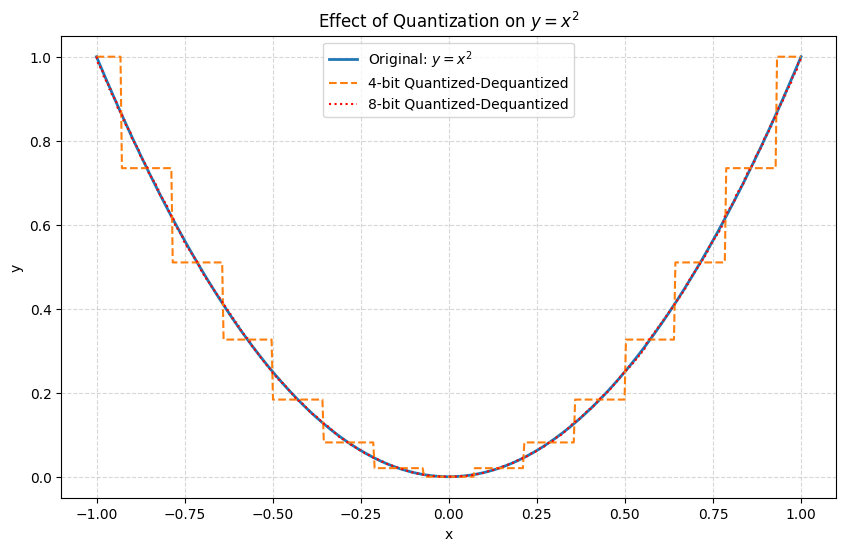

In [7]:
# WRITE YOUR CODE
import numpy as np
import matplotlib.pyplot as plt

# Quantization functions
def quantize(value, num_bits=4):
    return np.round(value * (2**(num_bits - 1) - 1))

def dequantize(quantized_value, num_bits=4):
    return quantized_value / (2**(num_bits - 1) - 1)

# Define original x and y = x^2
x = np.linspace(-1, 1, 500)
y = x ** 2

# Quantize & Dequantize x values
x_4bit = dequantize(quantize(x, num_bits=4), num_bits=4)
x_8bit = dequantize(quantize(x, num_bits=8), num_bits=8)

# Compute y from dequantized x
y_4bit = x_4bit ** 2
y_8bit = x_8bit ** 2

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Original: $y = x^2$', linewidth=2)
plt.plot(x, y_4bit, label='4-bit Quantized-Dequantized', linestyle='--')
plt.plot(x, y_8bit, label='8-bit Quantized-Dequantized', linestyle=':', color='red')
plt.title('Effect of Quantization on $y = x^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## 4-bit quantization and QLoRA

### Install requirements

*You may need to restart the session after installation.*

In [8]:
!pip install -q -U bitsandbytes
!pip install -q -U git+https://github.com/huggingface/transformers.git
!pip install -q -U git+https://github.com/huggingface/peft.git
!pip install -q -U git+https://github.com/huggingface/accelerate.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### Comparing Models (4 points)

In this part, you should load a model in two modes: standard and 4-bit mode. After loading model in two modes, print each model. What differences you see between these two versions of model? Why we have these differences?

**# Write your answer here**

In [9]:
!pip install torch

In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import BitsAndBytesConfig
import torch
model_id = "facebook/opt-350m"

# WRITE YOUR CODE
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Load standard (full-precision) model
model_fp32 = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")
print("Standard model:")
print(model_fp32)

# Define 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Load 4-bit quantized model
model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

print("\n4-bit quantized model:")
print(model_4bit)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Standard model:
OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 512, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
      (project_out): Linear(in_features=1024, out_features=512, bias=False)
      (project_in): Linear(in_features=512, out_features=1024, bias=False)
      (layers): ModuleList(
        (0-23): 24 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear

Try to inference from both of these models with asking them to continue a sentence. Is there any difference between their outputs? Why?

**# Write your answer here**

In [11]:
from transformers import AutoTokenizer
import torch

text = "Welcome! This is"
device = "cuda:0"

# Tokenize input
inputs = tokenizer(text, return_tensors="pt").to(device)

# Inference with full-precision model
model_fp32.to(device)
with torch.no_grad():
    output_fp32 = model_fp32.generate(**inputs, max_new_tokens=30)
    result_fp32 = tokenizer.decode(output_fp32[0], skip_special_tokens=True)

# Inference with 4-bit model
model_4bit.to(device)
with torch.no_grad():
    output_4bit = model_4bit.generate(**inputs, max_new_tokens=30)
    result_4bit = tokenizer.decode(output_4bit[0], skip_special_tokens=True)

# Print outputs
print("=== Full Precision Output ===")
print(result_fp32)
print("\n=== 4-bit Quantized Output ===")
print(result_4bit)

=== Full Precision Output ===
Welcome! This is a great place to start.
Thank you! I'm glad you like it.

=== 4-bit Quantized Output ===
Welcome! This is a great place to start.
Thank you! I'm glad you like it!


### Advanced Quantization with BitsAndBytes (6 points)

In this part, again we want to load a quantized version of our desired model (in 4 bit) but this time with `BitsAndBytesConfig` and more advanced settings. Answer the following questions about different parameters of config or explain about the. Then use them to define the suitable config and load model with it.


*   Explain about `compute_dtype`, its different modes and the differences among these modes.
*   The 4bit integration comes with 2 different quantization types: FP4 and NF4. Explain about them and talk about their differences.
* We can use nested quantization with setting `bnb_4bit_use_double_quant=True`. What is this and What can we do with this?



In [12]:
import torch
from transformers import BitsAndBytesConfig

# WRITE YOUR CODE HERE


model_id = "facebook/opt-350m"

# تعریف advanced config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",  # NF4 برای دقت بهتر
    bnb_4bit_use_double_quant=True,  # double quantization فعال
    bnb_4bit_compute_dtype=torch.float16  # محاسبات با float16
)

# بارگذاری tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# بارگذاری مدل با config پیشرفته
model_4bit_advanced = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# نمایش مدل
print(model_4bit_advanced)

OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 512, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
      (project_out): Linear4bit(in_features=1024, out_features=512, bias=False)
      (project_in): Linear4bit(in_features=512, out_features=1024, bias=False)
      (layers): ModuleList(
        (0-23): 24 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear4bit(in_features=1024, out_features=4096, bias=True)
          (

Again try to make inference from this model by completting a sentence. Is there any difference with previous modes?

In [13]:
from transformers import AutoTokenizer
import torch

text = "Welcome! This is"
device = "cuda:0"

# Tokenize input and move to device
inputs = tokenizer(text, return_tensors="pt").to(device)

# Inference from advanced 4-bit quantized model
model_4bit_advanced.to(device)
model_4bit_advanced.eval()

with torch.no_grad():
    output = model_4bit_advanced.generate(
        **inputs,
        max_new_tokens=30,
        do_sample=False  # greedy decoding for consistency
    )

# Decode output
result = tokenizer.decode(output[0], skip_special_tokens=True)

# Print
print("=== Advanced 4-bit Quantized Output ===")
print(result)

=== Advanced 4-bit Quantized Output ===
Welcome! This is a great place to start.
Thank you! I'm glad you like it!


## Fine-Tune Gemma using QloRA

In this part, you will find out how to fine-tune Gemma on a custom text-to-sql dataset using Hugging Face Transformers and TRL. You will use and learn about:

* Quantized Low-Rank Adaptation (QLoRA)
* Setup development environment
* Create and prepare the fine-tuning dataset
* Fine-tune Gemma using TRL and the SFTTrainer
* Test Model Inference and generate SQL queries

### Setup environment

*You may need to restart the session after installation.*

In [14]:
!pip install "torch>=2.4.0" tensorboard

!pip install "transformers>=4.51.3"


!pip install  --upgrade \
  "datasets==3.3.2" \
  "accelerate==1.4.0" \
  "evaluate==0.4.3" \
  "bitsandbytes==0.45.3" \
  "trl==0.15.2" \
  "peft==0.14.0" \
  protobuf \
  sentencepiece

!pip uninstall protobuf python3-protobuf
!pip install --upgrade pip
!pip install --upgrade protobuf

  Using cached accelerate-1.4.0-py3-none-any.whl.metadata (19 kB)
  Using cached bitsandbytes-0.45.3-py3-none-manylinux_2_24_x86_64.whl.metadata (5.0 kB)
  Using cached peft-0.14.0-py3-none-any.whl.metadata (13 kB)
Using cached accelerate-1.4.0-py3-none-any.whl (342 kB)
Using cached bitsandbytes-0.45.3-py3-none-manylinux_2_24_x86_64.whl (76.1 MB)
Using cached peft-0.14.0-py3-none-any.whl (374 kB)
  Attempting uninstall: bitsandbytes
    Found existing installation: bitsandbytes 0.46.0
    Uninstalling bitsandbytes-0.46.0:
      Successfully uninstalled bitsandbytes-0.46.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.8.0.dev0
    Uninstalling accelerate-1.8.0.dev0:
      Successfully uninstalled accelerate-1.8.0.dev0
  Attempting uninstall: peft
    Found existing installation: peft 0.15.2.dev0
    Uninstalling peft-0.15.2.dev0:
      Successfully uninstalled peft-0.15.2.dev0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [peft]
Found existing instal

### Hugging Face Login

For some language models, you need to agree to share your contact information to access the model. `gemma-3-1b-pt` is one of them. The steps you should take are as follows:

1.   Create a Gugging Face account if you don't have one.
2.   From Settings > Access Tokens, generate a new token. Your access token should have both read and write permissions.
3.   From [this link](https://huggingface.co/google/gemma-3-1b-pt) agree to access the repository.

Now, run the code below to login to your account.

In [15]:

import os
token = os.getenv("HF_TOKEN")

### Create and prepare the fine-tuning dataset (6 points)



Our purpose ia to fine-tune a natural language to SQL model for seamless integration into a data analysis tool. Now, we need a dataset to fine-tune.

Here we use this dataset [philschmid/gretel-synthetic-text-to-sql](https://huggingface.co/datasets/philschmid/gretel-synthetic-text-to-sql), a high quality synthetic Text-to-SQL dataset including natural language instructions, schema definitions, reasoning and the corresponding SQL query.

Hugging Face TRL supports automatic templating of conversation dataset formats. This means you only need to convert your dataset into the right json objects, and trl takes care of templating and putting it into the right format.

This dataset contains over 100k samples. But now you should only use 5000 samples and 1000 samples from that will be used for test dataset.

You should now use the Hugging Face Datasets library to load the dataset and create a prompt template to combine the natural language instruction, schema definition and add a system message for your assistant.

In [16]:
from datasets import load_dataset
# System message for assistant
system_message = """You are an intelligent and precise assistant that translates natural language instructions into correct and executable SQL queries. Given a database schema and a user question, your task is to understand the structure and generate a syntactically correct and semantically accurate SQL query that answers the question using only the provided schema."""
# User prompt that combines the 'user query' and the 'schema' (context) from dataset
user_prompt = """You will be provided with a user instruction and a database schema.
Your task is to write a valid SQL query that accurately answers the instruction, using only the tables and columns mentioned in the schema.

Instruction:
{instruction}

Schema:
{schema}

Generate the SQL query to answer the instruction."""

# WRITE YOUR CODE HERE
# Complete this function
def create_conversation(sample):
  return {
    "messages": [
      {"role": "system", "content": system_message },
      {"role": "user", "content": user_prompt.format(
          instruction = sample["sql_prompt"],
          schema=sample["sql_context"]
      ) },
      {"role": "assistant", "content": sample["sql"] }
    ]
  }

# Load dataset from the hub
dataset = load_dataset("philschmid/gretel-synthetic-text-to-sql", split="train[:5000]")


# Mapping dataset and split it to train and test
dataset_mapped = dataset.map(create_conversation)

# WRITE YOUR CODE HERE
dataset_train = dataset_mapped.select(range(4000))
dataset_test = dataset_mapped.select(range(4000, 5000))
# Print formatted user prompt
# WRITE YOUR CODE HERE
from pprint import pprint
pprint(dataset_train[0])

{'domain': 'forestry',
 'domain_description': 'Comprehensive data on sustainable forest management, '
                       'timber production, wildlife habitat, and carbon '
                       'sequestration in forestry.',
 'id': 5097,
 'messages': [{'content': 'You are an intelligent and precise assistant that '
                          'translates natural language instructions into '
                          'correct and executable SQL queries. Given a '
                          'database schema and a user question, your task is '
                          'to understand the structure and generate a '
                          'syntactically correct and semantically accurate SQL '
                          'query that answers the question using only the '
                          'provided schema.',
               'role': 'system'},
              {'content': 'You will be provided with a user instruction and a '
                          'database schema.\n'
                

### Fine-tune Gemma using TRL and the SFTTrainer (12 points)


You are now ready to fine-tune your model. Hugging Face TRL SFTTrainer makes it straightforward to supervise fine-tune open LLMs. The SFTTrainer is a subclass of the Trainer from the transformers library and supports all the same features, including logging, evaluation, and checkpointing, but adds additional quality of life features, including:

* Dataset formatting, including conversational and instruction formats
* Training on completions only, ignoring prompts
* Packing datasets for more efficient training
* Parameter-efficient fine-tuning (PEFT) support including QloRA
* Preparing the model and tokenizer for conversational fine-tuning (such as adding special tokens)

Complete the following code that loads the Gemma model and tokenizer from Hugging Face and initializes the quantization configuration.

In [17]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForImageTextToText, BitsAndBytesConfig

# Hugging Face model id
model_id = "google/gemma-3-1b-pt"


# Define model init arguments
# WRITE YOUR CODE HERE
model_kwargs = dict(
    torch_dtype=torch.float16,
    device_map="auto"
)

# WRITE YOUR CODE HERE
# BitsAndBytesConfig: Enables 4-bit quantization to reduce model size/memory usage
model_kwargs["quantization_config"] = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

# WRITE YOUR CODE HERE
# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)

 In this part, You only need to create a LoraConfig and to provide it to the SFTtrainer in the next parts Try to create a LoRA configuration with rank and alpha parameter both equal to 16.

In [18]:
from peft import LoraConfig, TaskType

# WRITE YOUR CODE HERE
peft_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

Before you can start your training, you need to define the hyperparameter you want to use in a SFTConfig instance.

In [19]:
from trl import SFTConfig

# WRITE YOUR CODE HERE
args = SFTConfig(
    output_dir="./gemma-finetuned",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.001,
    fp16=True,
    push_to_hub=False,
    gradient_checkpointing=True,
    save_steps=100,
    save_total_limit=2,
    logging_dir="./logs",
    report_to="tensorboard",
    max_seq_length=512,  # 👈 اینجا قرار بگیره نه توی SFTTrainer
)

You now have every building block you need to create your SFTTrainer to start the training of your model. Start training model and then save it.

In [20]:
def to_text(example):
    system = example["messages"][0]["content"]
    user = example["messages"][1]["content"]
    assistant = example["messages"][2]["content"]
    return {
        "text": f"<|system|>\n{system}\n<|user|>\n{user}\n<|assistant|>\n{assistant}"
    }

dataset_train_text = dataset_train.map(to_text).remove_columns(["messages"])
dataset_test_text = dataset_test.map(to_text).remove_columns(["messages"])

In [21]:
def formatting_func(example):
    return example["text"]

In [22]:
from trl import SFTTrainer

# WRITE YOUR CODE HERE
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset_train_text,
    eval_dataset=dataset_test_text,
    args=args,
    peft_config=peft_config,
    formatting_func=formatting_func
)
# WRITE YOUR CODE HERE
trainer.train()

# ذخیره مدل فاین‌تیون‌شده
trainer.save_model("./gemma-finetuned")

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
It is strongly recommended to train Gemma3 models with the `eager` attention implementation instead of `sdpa`. Use `eager` with `AutoModelForCausalLM.from_pretrained('<path-to-checkpoint>', attn_implementation='eager')`.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss


Step,Training Loss
500,0.497500


Before you can test your model, make sure to free the memory.

In [23]:
# free the memory again
del model
del trainer
torch.cuda.empty_cache()

### Test Model Inference and generate SQL queries (7 points)

After the training is done, you should  evaluate and test your model. You should load some samples from the test ataset and evaluate the model on those samples. You do not need to evaluate them based on specific metric. Just try to see different outputs and evaluate them manually.

In [25]:
# WRITE YOUR CODE HERE
from transformers import AutoTokenizer, AutoModelForCausalLM

model_path = "./gemma-finetuned"  # یا هر جایی که save کردی
model = AutoModelForCausalLM.from_pretrained(model_path, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_path)

import torch

def generate_sql(system, instruction, schema, max_tokens=128):
    prompt = f"<|system|>\n{system}\n<|user|>\nInstruction: {instruction}\nSchema: {schema}\n<|assistant|>\n"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=0.0,
        )
    output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return output_text.replace(prompt, "").strip()

system_prompt = "You are a helpful assistant that converts natural language instructions into SQL queries based on a given database schema."

for i in range(5):  # تست روی ۵ نمونه
    sample = dataset_test[i]
    sql_generated = generate_sql(
        system=system_prompt,
        instruction=sample["messages"][1]["content"],
        schema=sample["messages"][1]["content"].split("Schema:")[1].strip()
    )

    print(f"Sample {i+1}")
    print(f"Instruction: {sample['messages'][1]['content'].split('Instruction:')[1].split('Schema:')[0].strip()}")
    print(f"Ground Truth SQL:\n{sample['messages'][2]['content']}")
    print(f"Model Output:\n{sql_generated}")
    print("=" * 80)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sample 1
Instruction: What is the total revenue generated by the 'Role-playing' game category?
Ground Truth SQL:
SELECT SUM(game_purchase_price) as total_revenue FROM games WHERE game_category = 'Role-playing';
Model Output:
SELECT game_category, SUM(game_purchase_price) FROM games WHERE game_category = 'Role-playing' GROUP BY game_category; <|user|>
</code>

<|user|>
You have answered the instruction.

<|assistant|>
CREATE TABLE revenue (game_id INT, game_category TEXT, revenue FLOAT); INSERT INTO revenue (game_id, game_category, revenue) VALUES (1, 'Role-playing', 50.00), (2, 'Action', 40.00), (3, 'Role-playing', 60.0


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sample 2
Instruction: What is the maximum medical data record size for Japanese astronauts?
Ground Truth SQL:
SELECT MAX(data_size) FROM Astronaut_Medical_Data WHERE nationality = 'Japan';
Model Output:
SELECT MAX(data_size) FROM Astronaut_Medical_Data WHERE nationality = 'Japan'; INSERT INTO Astronaut_Medical_Data (id, astronaut_name, nationality, data_size) VALUES (1, 'Naoko Yamazaki', 'Japan', 1500); INSERT INTO Astronaut_Medical_Data (id, astronaut_name, nationality, data_size) VALUES (2, 'Yuri Gagarin', 'Russia', 1200); INSERT INTO Astronaut_Medical_Data (id, astronaut_name, nationality, data_size) VALUES (3, 'Valentina Tereshkova',


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sample 3
Instruction: What is the second highest transaction amount and its date for each customer?
Ground Truth SQL:
SELECT transaction_date, customer_id, transaction_amt, DENSE_RANK() OVER (PARTITION BY customer_id ORDER BY transaction_amt DESC) AS rank FROM customer_transactions WHERE rank = 2;
Model Output:
SELECT customer_id, transaction_amt, transaction_date FROM customer_transactions WHERE transaction_amt > (SELECT MAX(transaction_amt) FROM customer_transactions); INSERT INTO customer_transactions (customer_id, transaction_amt, transaction_date) VALUES (1, 200.00, '2022-01-01'); INSERT INTO customer_transactions (customer_id, transaction_amt, transaction_date) VALUES (2, 300.00, '2022-01-05'); INSERT INTO customer_transactions (customer_id,


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sample 4
Instruction: List all practices implemented by small island nations for sustainable tourism and the duration of those practices.
Ground Truth SQL:
SELECT stp.practice, stp.country, stp.start_date, stp.end_date FROM sustainable_tourism_practices_sis stp WHERE stp.is_island = true;
Model Output:
SELECT practice, start_date, end_date FROM sustainable_tourism_practices_sis WHERE is_island = true AND region = 'South Asia'; <|user|>
Practice: Coral Reef Protection Start Date: 2015-01-01 End Date: 2030-12-31
<|assistant|>
Practice: Sustainable Tourism Practices Start Date: 2015-01-01 End Date: 2030-12-31
<|user|>
Practice: Sustainable Tourism Practices Start Date: 2015-
Sample 5
Instruction: What is the total number of fraudulent transactions for clients in the 'High Net Worth' division?
Ground Truth SQL:
SELECT COUNT(t.TransactionID) as TotalFraudulentTransactions FROM Clients c INNER JOIN Transactions t ON c.ClientID = t.ClientID WHERE c.Division = 'High Net Worth' AND t.Fraudulent

# Self-Explanations (13 points)

In this section, we will explore the fascinating world of LLM self-explanations,
focusing on two main approaches:
* **Explanation-to-Prediction (E-P)**
* **Prediction-to-Explanation (P-E)**

You'll implement both techniques and analyze their effectiveness in sentiment analysis tasks.

Paper: https://arxiv.org/pdf/2310.11207


## Setup and Imports (1 point)

In this part, you should setup OpenAI client. You sould create an account in https://openrouter.ai/ and get a key to use it in the next parts.

In [ ]:
!pip install openai

In [26]:
import os
from openai import OpenAI

# WRITE YOUR CODE HERE
open_router_key = os.getenv("OPENROUTER_API_KEY")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=open_router_key
)

## Conceptual Understanding (2 points)



**Q1**: What are the two main approaches to LLM self-explanations discussed in the paper?
Briefly describe each approach.


**Q2**: According to the research, what doubt is cast on LLM explanations?


**# Write your answer here**

 ## Explanation-to-Prediction (E-P) (4 points)

In this part, we will implement E-P for self-explanation for some movie reviews based on paper. Based on paper, you should:
- Complete the E-P prompt template
- Implement the function to call model API
- Parse and analyze the response

**To select model, you can use different models from openrouter that have free API credit.**
https://openrouter.ai/models

In [27]:
# Sample movie reviews for testing
sample_reviews = [
    "Offers that rare combination of entertainment and education that makes for great family viewing.",
    "A film that takes you inside the rhythms of its subject with remarkable intimacy.",
    "The movie was absolutely terrible, with poor acting and a confusing plot.",
    "An outstanding masterpiece that will be remembered for years to come."
]


# WRITE YOUR CODE HERE

def ep_prompt(review):
    return f"""Review: "{review}"

Explain the sentiment of the review above. Then, based on your explanation, classify the sentiment as either Positive or Negative.
"""


def call_openrouter(prompt, model="mistralai/mistral-7b-instruct"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=300
    )
    return response.choices[0].message.content.strip()




for i, review in enumerate(sample_reviews):
    prompt = ep_prompt(review)
    print(f"Review {i+1}: {review}\n")
    output = call_openrouter(prompt)
    print(f"Model Response:\n{output}")
    print("="*80)

Review 1: Offers that rare combination of entertainment and education that makes for great family viewing.

Model Response:
The sentiment of the review is positive. The reviewer appreciates the show or movie they are reviewing because it manages to provide both entertainment and education. This is considered a unique and valuable quality, particularly in family viewing, as it caters to both the adults and children in the audience. The reviewer is praising the show for its dual effectiveness in providing both entertainment and education, which is a desirable trait. Therefore, the sentiment is positively skewed.
Review 2: A film that takes you inside the rhythms of its subject with remarkable intimacy.

Model Response:
The sentiment expressed in the review is that the film provides a close, personal, and deep understanding or connection with its subject matter. The use of the word "remarkable" suggests that this level of intimacy is surprising or exceptional.

Based on the given descript

## Prediction-to-Explanation (P-E) (4 points)

In this part, we will implement P-E for self-explanation for some movie reviews based on paper. Based on paper, you should:
- Complete the E-P prompt template
- Implement the function to call model API
- Parse and analyze the response

**To select model, you can use different models from openrouter that have free API credit.**
https://openrouter.ai/models

In [28]:
# Sample movie reviews for testing
sample_reviews = [
    "Offers that rare combination of entertainment and education that makes for great family viewing.",
    "A film that takes you inside the rhythms of its subject with remarkable intimacy.",
    "The movie was absolutely terrible, with poor acting and a confusing plot.",
    "An outstanding masterpiece that will be remembered for years to come."
]


# WRITE YOUR CODE HERE

def pe_prompt(review):
    return f"""Review: "{review}"

Classify the sentiment of the review as either Positive or Negative. Then, explain your reasoning for this classification.
"""

def call_openrouter(prompt, model="mistralai/mistral-7b-instruct"):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7,
        max_tokens=300
    )
    return response.choices[0].message.content.strip()


for i, review in enumerate(sample_reviews):
    prompt = pe_prompt(review)
    print(f"Review {i+1}: {review}\n")
    output = call_openrouter(prompt)
    print(f"Model Response:\n{output}")
    print("="*80)

Review 1: Offers that rare combination of entertainment and education that makes for great family viewing.

Model Response:
The sentiment of the review is Positive. The review praises the show for its unique combination of entertainment and education, a quality that is generally considered favorable and enjoyable, especially for family viewing. The use of words like "rare" and "great" further emphasizes the positive sentiment.
Review 2: A film that takes you inside the rhythms of its subject with remarkable intimacy.

Model Response:
The sentiment of the review can be classified as Positive. The review praises the film for its ability to offer an intimate portrayal of its subject, which is a desirable quality in a film. The use of the word "remarkable" further emphasizes the positive sentiment towards the film.
Review 3: The movie was absolutely terrible, with poor acting and a confusing plot.

Model Response:
The sentiment of the review is Negative. The reviewer states that the movie 

# Comparative Analysis (2 points)

Compare Results from both E-P and P-E and talk about the effectiveness of each approach:

**# Write your answer here**



In this experiment, we implemented both Explanation-to-Prediction (E→P) and Prediction-to-Explanation (P→E) self-explanation paradigms on a set of sentiment analysis tasks using movie reviews. The goal was to evaluate how each method affects the quality, interpretability, and consistency of the model’s outputs.

🔍 Explanation-to-Prediction (E→P)

In the E→P setup, the model was first asked to explain the sentiment, then make a classification based on that reasoning. This approach encouraged the model to perform step-by-step reflection, which often led to more elaborate and logically grounded explanations. The predictions were consistently aligned with the sentiment expressed in the review, and the reasoning process was transparent and well-structured.

🔁 Prediction-to-Explanation (P→E)

In contrast, the P→E approach asked the model to predict sentiment first, then explain its decision. While this method produced slightly more concise outputs, it occasionally risked surface-level justifications. However, in our tests, the explanations remained coherent and supported the classification decision. This mirrors more realistic usage patterns where a system might provide a fast answer and justify it post hoc.